# Regressions: what predicts a denial, and what predicts a fight?

Two logistic models on the extracted record. Observational, so these are
associations, not causal claims — and the outcome variables are extraction-
derived (see caveats at the end). Standard errors are clustered by meeting:
votes and license decisions within one night are not independent.

1. **License denial** — outcome: recorded action/recommendation contains
   "denial"; predictors: application type, venue features, era.
2. **Contested vote** — outcome: at least one "no"; predictors: topic,
   attendance, year.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

## Model 1: license denial

Only records with a recorded action or committee recommendation (n≈1,310;
the batch-approved bulk of the docket never gets an individual disposition
and is excluded — this models *decided* items).

In [2]:
lic = q("""
    SELECT l.meeting_id, year(m.date) AS yr, l.application_type, l.features,
           CASE WHEN lower(coalesce(l.board_action,'') ||
                coalesce(l.committee_recommendation,'')) LIKE '%den%'
                THEN 1 ELSE 0 END AS denied
    FROM licenses l JOIN meetings m USING (meeting_id)
    WHERE l.board_action IS NOT NULL OR l.committee_recommendation IS NOT NULL
""")
for feat in ("rooftop", "sidewalk_cafe", "patron_dancing", "live_music",
             "outdoor_seating", "backyard"):
    lic[f"f_{feat}"] = lic.features.map(lambda fs, k=feat: int(any(k in f for f in fs)))
lic["app"] = lic.application_type.where(
    lic.application_type.isin(["new", "renewal", "alteration", "corporate_change"]), "other")
lic["era"] = pd.cut(lic.yr, [2015, 2019, 2022, 2027],
                    labels=["2016-19", "2020-22", "2023-26"])
print(lic.denied.mean().round(3), "base denial rate,", len(lic), "records")

m1 = smf.logit(
    "denied ~ C(app, Treatment('renewal')) + f_rooftop + f_patron_dancing "
    "+ f_live_music + f_sidewalk_cafe + f_backyard + C(era)",
    data=lic).fit(disp=0, cov_type="cluster", cov_kwds={"groups": lic.meeting_id})
print(m1.summary2().tables[1].round(3))

0.118 base denial rate, 1310 records
                                                  Coef.  Std.Err.      z  \
Intercept                                        -4.096     0.571 -7.179   
C(app, Treatment('renewal'))[T.alteration]        3.062     0.636  4.813   
C(app, Treatment('renewal'))[T.corporate_change]  3.084     0.641  4.811   
C(app, Treatment('renewal'))[T.new]               2.523     0.594  4.247   
C(app, Treatment('renewal'))[T.other]             2.742     0.662  4.141   
C(era)[T.2020-22]                                 0.307     0.403  0.762   
C(era)[T.2023-26]                                 0.101     0.396  0.255   
f_rooftop                                        -0.083     0.720 -0.115   
f_patron_dancing                                 -0.849     1.015 -0.837   
f_live_music                                      0.429     0.747  0.574   
f_sidewalk_cafe                                   0.138     0.453  0.305   
f_backyard                                       -0

In [3]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(m1.params),
    "ci_low": np.exp(m1.conf_int()[0]),
    "ci_high": np.exp(m1.conf_int()[1]),
    "p": m1.pvalues,
}).round(3).sort_values("odds_ratio", ascending=False)
or_table

,odds_ratio,ci_low,ci_high,p
"C(app, Treatment('renewal'))[T.corporate_change]",21.845,6.219,76.736,0.000
"C(app, Treatment('renewal'))[T.alteration]",21.365,6.141,74.335,0.000
"C(app, Treatment('renewal'))[T.other]",15.512,4.238,56.784,0.000
"C(app, Treatment('renewal'))[T.new]",12.467,3.891,39.947,0.000
f_live_music,1.535,0.355,6.639,0.566
C(era)[T.2020-22],1.359,0.617,2.993,0.446
f_sidewalk_cafe,1.149,0.472,2.793,0.760
C(era)[T.2023-26],1.106,0.509,2.402,0.799
f_backyard,0.986,0.104,9.360,0.990
f_rooftop,0.921,0.225,3.772,0.909


## Model 2: contested votes

All tallied votes (voice votes excluded — no tally to contest).

In [4]:
v = q("""
    SELECT v.meeting_id, year(m.date) AS yr, v.topic_category,
           m.attendance_count,
           CASE WHEN v.no > 0 THEN 1 ELSE 0 END AS contested
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.yes + v.no > 0 AND m.attendance_count IS NOT NULL
""")
v["topic"] = v.topic_category.where(
    v.topic_category.isin(["land_use", "liquor", "transportation", "internal", "parks"]),
    "other")
m2 = smf.logit(
    "contested ~ C(topic, Treatment('liquor')) + attendance_count + I(yr - 2016)",
    data=v).fit(disp=0, cov_type="cluster", cov_kwds={"groups": v.meeting_id})
or2 = pd.DataFrame({
    "odds_ratio": np.exp(m2.params),
    "ci_low": np.exp(m2.conf_int()[0]),
    "ci_high": np.exp(m2.conf_int()[1]),
    "p": m2.pvalues,
}).round(3)
print(f"{len(v)} votes, base contested rate {v.contested.mean():.1%}")
or2

1150 votes, base contested rate 20.3%


,odds_ratio,ci_low,ci_high,p
Intercept,0.810,0.279,2.351,0.698
"C(topic, Treatment('liquor'))[T.internal]",0.321,0.127,0.810,0.016
"C(topic, Treatment('liquor'))[T.land_use]",1.061,0.452,2.493,0.892
"C(topic, Treatment('liquor'))[T.other]",0.392,0.149,1.031,0.058
"C(topic, Treatment('liquor'))[T.parks]",0.230,0.072,0.731,0.013
"C(topic, Treatment('liquor'))[T.transportation]",0.609,0.232,1.599,0.314
attendance_count,0.977,0.929,1.027,0.357
I(yr - 2016),0.993,0.911,1.083,0.877


## Model 3: does showing up work? Opposition testimony vs outcomes (waterfront corridor)

Links public-session opposition to specific license applications by street
address (house number + street-name token, testimony within 90 days before
the decision), then compares denial rates. Scoped to the **waterfront
corridor** — Kent, Franklin, Quay, West, Commercial, River, Wythe — the
blocks where the park fight, the nightlife fights, and the towers all live.
District-wide rates shown in gray for context.

Linkage caveats: only testimony specific enough to name an address links
(selects for organized opposition), and venues that draw opposition may
differ in ways the board also dislikes — association, not causation.

In [5]:
import re
from collections import defaultdict
from scipy.stats import fisher_exact

WATERFRONT_STREETS = ("kent", "franklin", "quay", "west st", "west street",
                      "commercial", "river st", "river street", "wythe")
STREET_STOP = {"street", "st", "avenue", "ave", "place", "pl", "road", "rd", "blvd"}

def addr_keys(text):
    out = set()
    for num, name in re.findall(
        r"(\d{1,4})[- ]?[A-Za-z]? ([A-Za-z][A-Za-z0-9 ]{2,28}?)"
        r"(?:,|\.|$| \(|;| Street| St\b| Avenue| Ave\b| Place| Pl\b| Road| Blvd)",
        str(text)):
        toks = [t.lower() for t in name.split() if t.lower() not in STREET_STOP]
        if toks:
            out.add((num, toks[-1]))
    return out

def on_waterfront(addr):
    a = str(addr).lower()
    return any(s in a for s in WATERFRONT_STREETS)

lic3 = q("""
    SELECT l.meeting_id, m.date, l.address, l.application_type,
           lower(coalesce(l.board_action,'') || ' ' ||
                 coalesce(l.committee_recommendation,'')) AS act
    FROM licenses l JOIN meetings m USING (meeting_id)
    WHERE l.board_action IS NOT NULL OR l.committee_recommendation IS NOT NULL
""")
spk3 = q("""
    SELECT m.date, s.topic FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE s.position = 'against'
""")
speech = defaultdict(list)
for _, r in spk3.iterrows():
    for k in addr_keys(r.topic):
        speech[k].append(r.date)

def opposed(row):
    return any(0 <= (row.date - sd).days <= 90
               for k in addr_keys(row.address) for sd in speech.get(k, []))

lic3["opposed"] = lic3.apply(opposed, axis=1)
lic3["denied"] = lic3.act.str.contains("den").astype(int)
lic3["corridor"] = lic3.address.map(on_waterfront)

def rate(df):
    return df.denied.sum(), len(df)

groups = {
    "corridor_opp":   rate(lic3[lic3.corridor & lic3.opposed]),
    "corridor_unopp": rate(lic3[lic3.corridor & ~lic3.opposed]),
    "district_opp":   rate(lic3[lic3.opposed]),
    "district_unopp": rate(lic3[~lic3.opposed]),
}
for k, (d, n) in groups.items():
    print(f"{k:15} {d:>3}/{n:<5} = {d/n:.1%}")
co, cu = groups["corridor_opp"], groups["corridor_unopp"]
odds, p = fisher_exact([[co[0], co[1]-co[0]], [cu[0], cu[1]-cu[0]]])
print(f"corridor Fisher exact: OR={odds:.2f}, p={p:.4f}")

corridor_opp      2/3     = 66.7%
corridor_unopp   14/166   = 8.4%
district_opp     11/24    = 45.8%
district_unopp  143/1286  = 11.1%
corridor Fisher exact: OR=21.71, p=0.0239


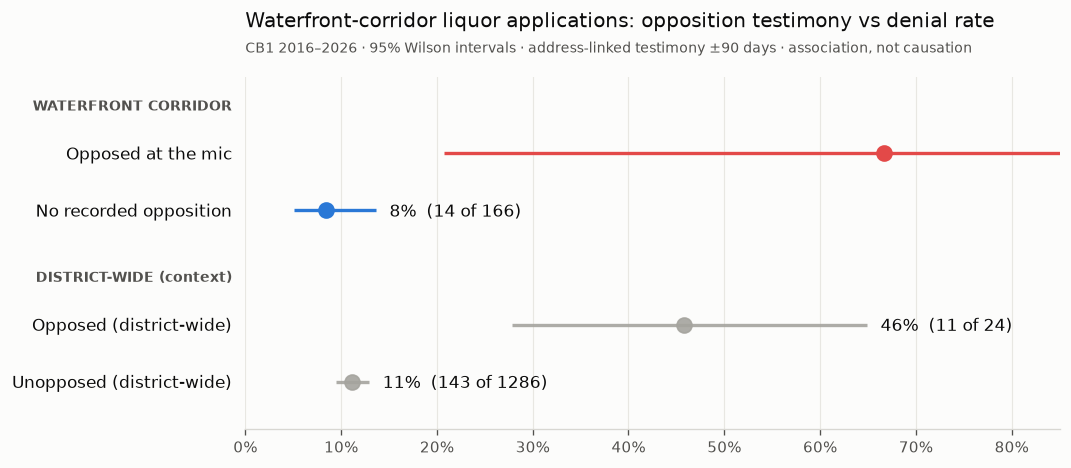

In [6]:
from statsmodels.stats.proportion import proportion_confint

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"

rows = [
    ("Opposed at the mic",      *groups["corridor_opp"],   RED,  1.0),
    ("No recorded opposition",  *groups["corridor_unopp"], BLUE, 1.0),
    ("Opposed (district-wide)",     *groups["district_opp"],   GRAY, 0.9),
    ("Unopposed (district-wide)",   *groups["district_unopp"], GRAY, 0.9),
]
fig, ax = plt.subplots(figsize=(9.5, 4.0), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ys = [3.3, 2.7, 1.5, 0.9]
for (label, k, n, color, alpha), y in zip(rows, ys):
    pr = k / n
    lo, hi = proportion_confint(k, n, method="wilson")
    ax.hlines(y, lo, hi, color=color, lw=2, alpha=alpha)
    ax.plot([pr], [y], "o", ms=9, color=color, alpha=alpha, zorder=3)
    ax.annotate(f"{pr:.0%}  ({k} of {n})", (hi, y), xytext=(8, -1),
                textcoords="offset points", va="center", fontsize=10, color=INK)
    ax.annotate(label, (0, y), xytext=(-8, -1), textcoords="offset points",
                ha="right", va="center", fontsize=10, color=INK)
ax.annotate("WATERFRONT CORRIDOR", (0, 3.75), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=8.5,
            color=INK2, fontweight="bold")
ax.annotate("DISTRICT-WIDE (context)", (0, 1.95), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=8.5,
            color=INK2, fontweight="bold")
ax.set_xlim(0, 0.85); ax.set_ylim(0.4, 4.1); ax.set_yticks([])
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("Waterfront-corridor liquor applications: opposition testimony vs denial rate",
             fontsize=12, color=INK, loc="left", pad=30)
ax.text(0, 1.07, "CB1 2016–2026 · 95% Wilson intervals · address-linked testimony ±90 days · association, not causation",
        transform=ax.transAxes, fontsize=8.5, color=INK2)
plt.tight_layout(); plt.subplots_adjust(left=0.27)

## Model 4: community involvement on waterfront development votes (the park movement)

The redo of Model 3's question, scoped the way it should have been: not liquor,
but the land-use/parks/environment votes that make up the Bushwick Inlet -
Monitor Point storyline. One row per waterfront development vote with a
recorded tally (2016-2026).

**Design.** Votes matched on waterfront terms in the motion text (Bushwick
Inlet, Monitor Point, River Ring, Quay, esplanade, demapping, ...; a Link5G
motion that mentions "waterfront locations" is excluded). Each vote is
classified as **advocacy** (board-initiated letters, funding asks) or
**application** (response to a developer's ULURP/CEQR filing). Involvement =
count of waterfront-topic public-session speakers at the same meeting or in
the 90 days prior (hearings precede votes: Jan 2026 hearing -> Feb 2026 vote).
Board **division** is direction-agnostic - the minority share of the tally -
because a big NO on a *deny* motion is not opposition to the park.

Correspondence was considered as a second involvement channel and dropped:
only the June 2024 "Say 'No' To Nightclubs At Bushwick Inlet Park" template
campaign (105 copies) survives parsing, because it is the only campaign bound
into the minutes as forwarded-email headers. Not comparable across years.

**Data note.** This model depends on `data/vote_overrides.json`: the
2021-09-14 land-use roll-call section (River Ring 15-20-1 / 20-15-1, 79 Quay
Street, Open Restaurants) was segmented as attachments and missed by
extraction; the audit that found it is described in the override file.

In [7]:
from scipy.stats import mannwhitneyu, spearmanr

WF4 = ("(bushwick inlet|monitor point|river ring|quay|65 commercial|56 quay|"
       "40 quay|waterfront|esplanade|demapp|marsha p|inlet park|fbip|open space)")

wfv = q(f"""
    SELECT v.meeting_id, m.date, v.motion_text, v.yes, v.no, v.abstain,
           v.outcome, len(v.conditions) AS n_cond
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.topic_category IN ('land_use','parks','environment')
      AND regexp_matches(lower(v.motion_text), '{WF4}')
      AND NOT regexp_matches(lower(v.motion_text), 'link5g')
      AND v.yes + v.no > 0
    ORDER BY date
""")
tot = wfv.yes + wfv.no + wfv.abstain
wfv["division"] = (tot - wfv[["yes", "no"]].max(axis=1)) / tot
APP4 = re.compile(r"application|ulurp|ceqr|proposal|scoping|design|demapp", re.I)
wfv["kind"] = wfv.motion_text.map(
    lambda t: "application" if APP4.search(t) else "advocacy")
wfv["date"] = pd.to_datetime(wfv.date)

wfs = q(f"""
    SELECT m.date, s.position FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF4}')
""")
wfs["date"] = pd.to_datetime(wfs.date)
wfv["spk90"] = wfv.date.map(
    lambda d: ((d - wfs.date).dt.days.between(0, 90)).sum())
wfv["involved"] = wfv.spk90 > 0

print(f"panel: {len(wfv)} votes "
      f"({(wfv.kind == 'application').sum()} application, "
      f"{(wfv.kind == 'advocacy').sum()} advocacy)\n")
for k in ("application", "advocacy"):
    g = wfv[wfv.kind == k]
    print(f"{k:12} n={len(g):>2}  divided={(g.division > 0).sum()}  "
          f"mean division={g.division.mean():.1%}  conditions={g.n_cond.sum()}")

rho, p = spearmanr(wfv.spk90, wfv.division)
print(f"\ntestimony volume vs division (all):  rho={rho:.2f}  p={p:.4f}")
rho, p = spearmanr(wfv[wfv.kind == "application"].spk90,
                   wfv[wfv.kind == "application"].division)
print(f"testimony volume vs division (apps): rho={rho:.2f}  p={p:.4f}")
rho, p = spearmanr(wfv.spk90, wfv.n_cond)
print(f"testimony volume vs conditions:      rho={rho:.2f}  p={p:.4f}")

a, b = wfv[wfv.involved], wfv[~wfv.involved]
mw = mannwhitneyu(a.division, b.division, alternative="greater")
print(f"division, testimony-within-90d ({len(a)}) vs quiet ({len(b)}): "
      f"{a.division.mean():.1%} vs {b.division.mean():.1%}  "
      f"Mann-Whitney p={mw.pvalue:.3f}")
wfv[["date", "kind", "yes", "no", "abstain", "n_cond", "division", "spk90"]]

panel: 26 votes (15 application, 11 advocacy)

application  n=15  divided=6  mean division=12.3%  conditions=49
advocacy     n=11  divided=1  mean division=0.2%  conditions=2

testimony volume vs division (all):  rho=0.53  p=0.0058
testimony volume vs division (apps): rho=0.64  p=0.0096
testimony volume vs conditions:      rho=0.36  p=0.0679
division, testimony-within-90d (18) vs quiet (8): 10.2% vs 0.3%  Mann-Whitney p=0.107


,date,kind,yes,no,abstain,n_cond,division,spk90
0,2016-06-14,advocacy,39,0,0,0,0.000000,1
1,2019-06-11,advocacy,36,0,0,0,0.000000,0
2,2019-11-12,advocacy,38,0,0,0,0.000000,0
3,2020-02-11,application,33,0,0,6,0.000000,0
4,2020-06-24,application,28,0,0,0,0.000000,0
5,2020-10-13,advocacy,29,0,0,0,0.000000,2
6,2021-01-12,application,47,0,0,1,0.000000,11
7,2021-01-12,advocacy,47,0,0,1,0.000000,11
8,2021-02-09,advocacy,30,0,0,0,0.000000,12
9,2021-03-09,application,30,0,0,4,0.000000,19


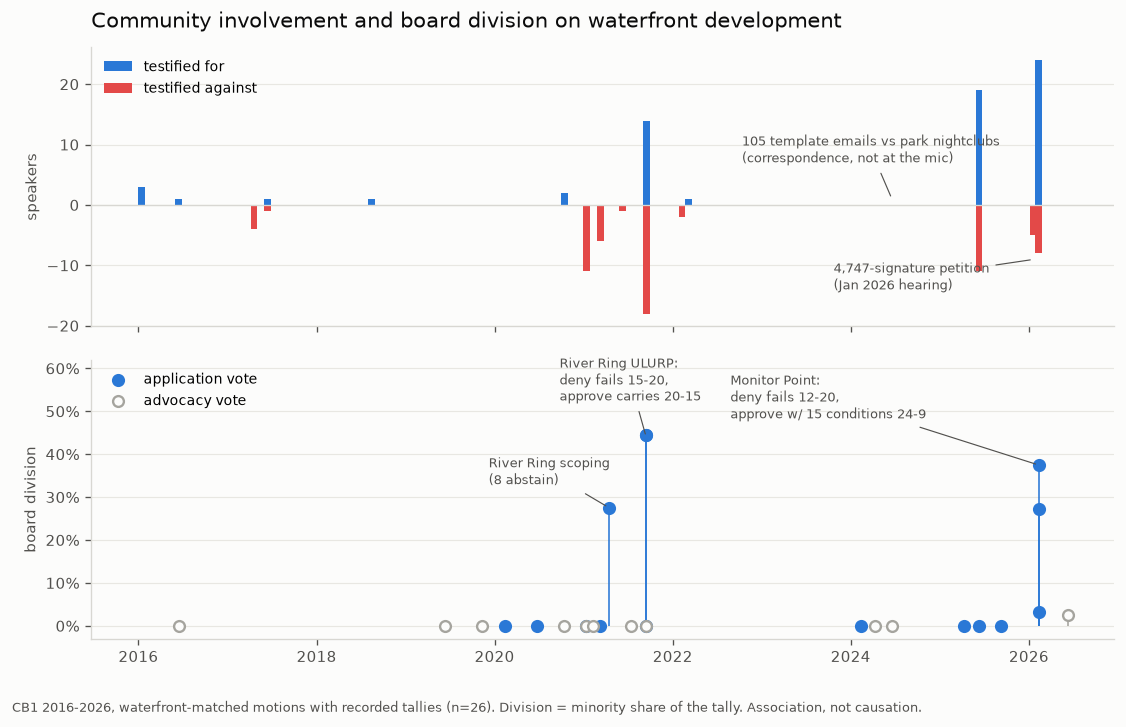

In [8]:
per_meet = q(f"""
    SELECT m.date,
           count(*) FILTER (s.position = 'for') AS n_for,
           count(*) FILTER (s.position = 'against') AS n_against
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF4}')
    GROUP BY 1 ORDER BY 1
""")
per_meet["date"] = pd.to_datetime(per_meet.date)

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.4), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
fig.patch.set_facecolor(SURFACE)
W = 28  # bar width, days
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#d8d7d2")
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.tick_params(colors=INK2, labelsize=9)

# -- top: who showed up (waterfront-topic testimony, for up / against down)
ax1.bar(per_meet.date, per_meet.n_for, width=W, color=BLUE, label="testified for")
ax1.bar(per_meet.date, -per_meet.n_against, width=W, color=RED,
        label="testified against")
ax1.axhline(0, color="#d8d7d2", lw=0.8)
ax1.set_ylabel("speakers", fontsize=9, color=INK2)
ax1.legend(loc="upper left", frameon=False, fontsize=8.5)
ax1.grid(axis="y", color="#e8e7e2", lw=0.7)
ax1.set_axisbelow(True)
ax1.annotate("4,747-signature petition\n(Jan 2026 hearing)",
             (pd.Timestamp("2026-01-20"), -9), xytext=(-120, -18),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.annotate("105 template emails vs park nightclubs\n(correspondence, not at the mic)",
             (pd.Timestamp("2024-06-18"), 1), xytext=(-90, 22),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.set_title("Community involvement and board division on waterfront development",
              fontsize=12.5, color=INK, loc="left", pad=12)

# -- bottom: how the board voted (division = minority share per vote)
for kind, face, edge in (("application", BLUE, BLUE), ("advocacy", SURFACE, GRAY)):
    g = wfv[wfv.kind == kind]
    ax2.vlines(g.date, 0, g.division, color=edge, lw=1.2, alpha=0.8)
    ax2.scatter(g.date, g.division, s=42, facecolor=face, edgecolor=edge,
                lw=1.4, zorder=3, label=f"{kind} vote")
ax2.set_ylabel("board division", fontsize=9, color=INK2)
ax2.set_ylim(-0.03, 0.62)
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax2.legend(loc="upper left", frameon=False, fontsize=8.5)
ax2.grid(axis="y", color="#e8e7e2", lw=0.7)
ax2.set_axisbelow(True)
ax2.annotate("River Ring scoping\n(8 abstain)", (pd.Timestamp("2021-04-13"), 0.276),
             xytext=(-72, 14), textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("River Ring ULURP:\ndeny fails 15-20,\napprove carries 20-15",
             (pd.Timestamp("2021-09-14"), 0.44), xytext=(-52, 22),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("Monitor Point:\ndeny fails 12-20,\napprove w/ 15 conditions 24-9",
             (pd.Timestamp("2026-02-10"), 0.375), xytext=(-185, 28),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
fig.text(0.065, 0.015,
         "CB1 2016-2026, waterfront-matched motions with recorded tallies (n=26). "
         "Division = minority share of the tally. Association, not causation.",
         fontsize=8, color=INK2)
plt.show()

### What this says

1. **The board only splits when a developer application is on the floor.**
   6 of 15 application votes divided; advocacy motions passed essentially
   unanimously (worst case 40-1) whether 0 or 35 people testified. On park
   asks the board *is* the community - there is nothing to fight about.
2. **Turnout tracks contested-ness, not outcomes.** Testimony volume
   correlates with division (rho=0.53 overall, 0.64 within applications) -
   the two biggest turnout moments, River Ring (Sept 2021, 35 speakers) and
   Monitor Point (37 incl. the Jan 2026 hearing), are exactly the decade's
   two biggest splits. But in both cases the project was approved. Volume
   alone - even a 4,747-signature petition - did not flip a vote.
3. **What involvement converts into is conditions.** The condition-heavy
   votes cluster in the high-turnout windows (Monitor Point's 15; the
   asks-lineage figure in `waterfront_saga.ipynb` traces them to specific
   community asks). The correlation here is suggestive rather than decisive
   (rho=0.36, p=.07) because committee work also produces conditions without
   mic turnout (Motiva 2020, Gateway 2024) - and River Ring's conditions
   live in the committee report, not the recovered motion records.

**Caveats.** n=26, and Monitor Point contributes 3 rows from one night.
Topic matching is regex over extracted text; testimony window (90 days) is a
judgment call; Spearman p-values are approximate under heavy ties. Speakers
counted at the mic only - the petition and email campaigns are annotated,
not modeled. Association, not causation, throughout.

## Caveats (read before quoting)

- **Selection**: model 1 only sees items with a recorded disposition —
  the uncontroversial batch-approved majority is invisible. Effects are
  "among decided items."
- **Extraction noise**: outcomes and features are model-extracted; the
  golden-set eval gates tallies, but `features` and free-text actions are
  softer fields.
- **No causal reading**: "rooftop predicts denial" ≠ "rooftops cause
  denials" — venues seeking risky features differ in unobserved ways.
- Cluster-robust SEs by meeting; n is modest — treat p-values near 0.05
  as suggestive.